In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv('Dataset -cognifiz.csv',encoding='latin1')
print("Data loaded! Total restaurants:", len(df))
df.head()

Data loaded! Total restaurants: 9551


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# Level 1 - Task 1: Top Cuisines

TOP 3 CUISINES:
North Indian: 3960 (41.5%)
Chinese: 2735 (28.6%)
Fast Food: 1986 (20.8%)


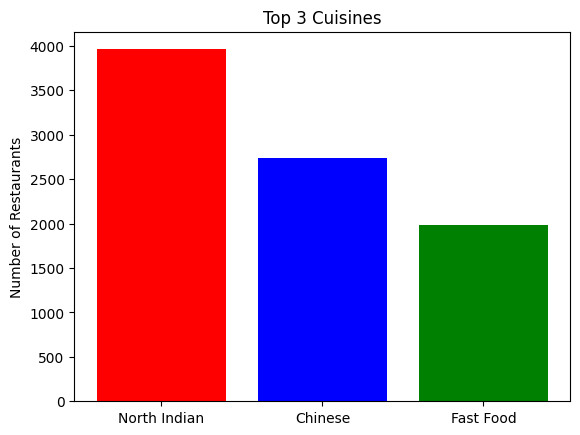

In [4]:
all_cuisines = []
for item in df['Cuisines'].dropna():
    for c in item.split(','):
        all_cuisines.append(c.strip())

top3 = Counter(all_cuisines).most_common(3)
print("TOP 3 CUISINES:")
for name, count in top3:
    print(f"{name}: {count} ({count/len(df)*100:.1f}%)")

plt.bar([x[0] for x in top3], [x[1] for x in top3], color=['red','blue','green'])
plt.title('Top 3 Cuisines')
plt.ylabel('Number of Restaurants')
plt.show()

# Level 1 - Task 2: City Analysis

In [8]:
print("CITY ANALYSIS:")
top_city = df['City'].value_counts().idxmax()
top_count = df['City'].value_counts().max()
print(f"Most restaurants: {top_city} ({top_count})")

city_ratings = df.groupby('City')['Aggregate rating'].mean()
best_city = city_ratings.idxmax()
print(f"Highest rated city: {best_city} ({city_ratings.max():.2f} stars)")

CITY ANALYSIS:
Most restaurants: New Delhi (5473)
Highest rated city: Inner City (4.90 stars)


# Level 1 - Task 3: Price Range Distribution

PRICE RANGE:
Range 1: 4444 restaurants (46.5%)
Range 2: 3113 restaurants (32.6%)
Range 3: 1408 restaurants (14.7%)
Range 4: 586 restaurants (6.1%)


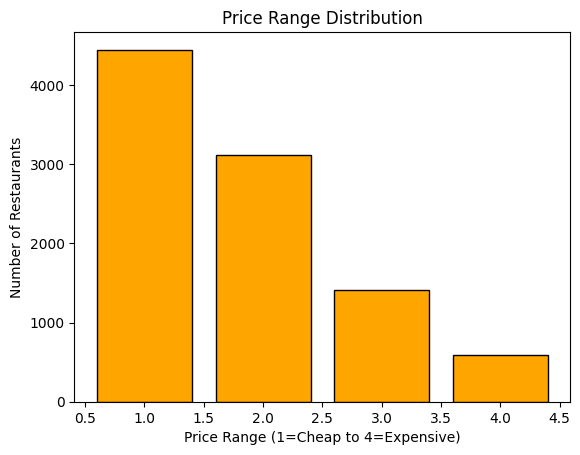

In [10]:
print("PRICE RANGE:")
price = df['Price range'].value_counts().sort_index()
for p, c in price.items():
    print(f"Range {p}: {c} restaurants ({c/len(df)*100:.1f}%)")

plt.bar(price.index, price.values, color='orange', edgecolor='black')
plt.title('Price Range Distribution')
plt.xlabel('Price Range (1=Cheap to 4=Expensive)')
plt.ylabel('Number of Restaurants')
plt.show()

# Level 1 - Task 4: Online Delivery

ONLINE DELIVERY:
With delivery: 25.7%
With delivery rating: 3.25
Without delivery rating: 2.47


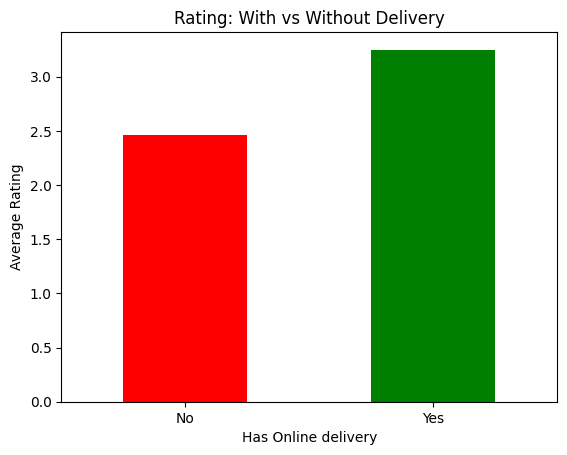

In [11]:
print("ONLINE DELIVERY:")
yes = (df['Has Online delivery'] == 'Yes').sum()
print(f"With delivery: {yes/len(df)*100:.1f}%")

avg = df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(f"With delivery rating: {avg['Yes']:.2f}")
print(f"Without delivery rating: {avg['No']:.2f}")

avg.plot(kind='bar', color=['red','green'], title='Rating: With vs Without Delivery')
plt.xticks(rotation=0)
plt.ylabel('Average Rating')
plt.show()

# Level 2 - Task 1: Restaurant Ratings

RATING DISTRIBUTION:
Average votes: 157


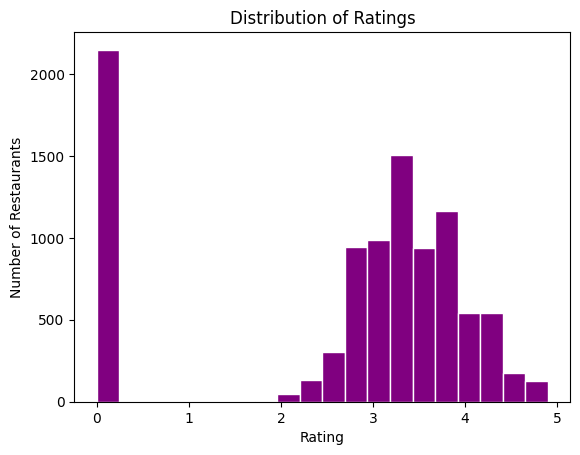

In [12]:
print("RATING DISTRIBUTION:")
print(f"Average votes: {df['Votes'].mean():.0f}")

plt.hist(df['Aggregate rating'], bins=20, color='purple', edgecolor='white')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()

# Level 2 - Task 2: Cuisine Combinations

In [13]:
print("TOP CUISINE COMBINATIONS:")
print(df['Cuisines'].value_counts().head(10))

print("\nHighest rated cuisine combos:")
top_rated = df.groupby('Cuisines')['Aggregate rating'].mean()
top_rated = top_rated.sort_values(ascending=False).head(5)
print(top_rated)

TOP CUISINE COMBINATIONS:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Highest rated cuisine combos:
Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Name: Aggregate rating, dtype: float64


# Level 2 - Task 3: Geographic Map

RESTAURANT MAP:


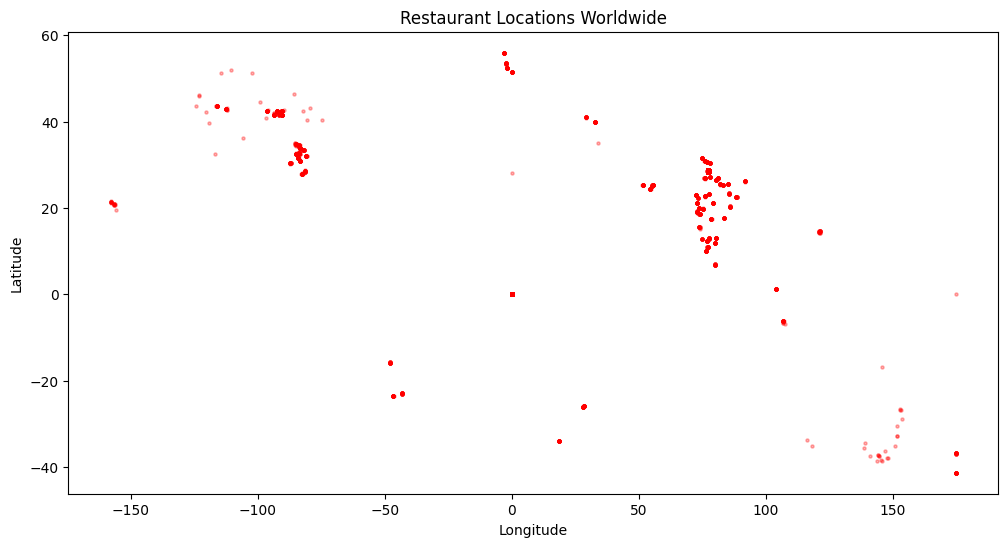

In [14]:
print("RESTAURANT MAP:")
plt.figure(figsize=(12,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.3, s=5, c='red')
plt.title('Restaurant Locations Worldwide')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Level 2 - Task 4: Restaurant Chains

RESTAURANT CHAINS:
Total chains found: 734

Top 10 Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


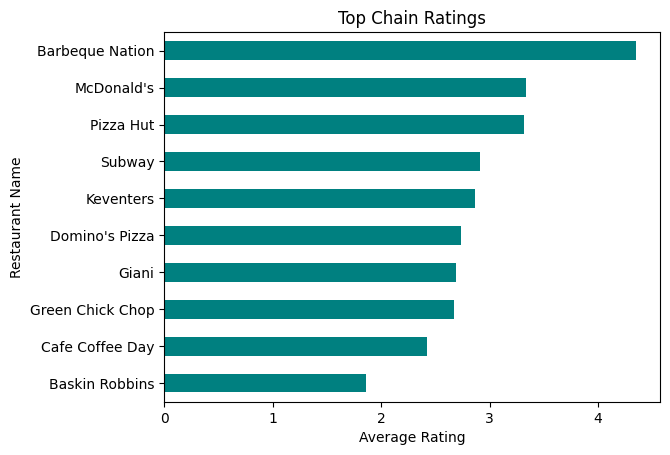

In [15]:
print("RESTAURANT CHAINS:")
chains = df['Restaurant Name'].value_counts()
chains = chains[chains > 1]
print(f"Total chains found: {len(chains)}")
print("\nTop 10 Chains:")
print(chains.head(10))

top10 = chains.head(10).index
ratings = df[df['Restaurant Name'].isin(top10)].groupby('Restaurant Name')['Aggregate rating'].mean()
ratings.sort_values().plot(kind='barh', color='teal', title='Top Chain Ratings')
plt.xlabel('Average Rating')
plt.show()